# Clasificación de Residuos — Modelo D1: EfficientNetV2B0 Top

---

## Contexto del Experimento

Este notebook forma parte de una **serie de experimentos de Transfer Learning** que aplica la técnica de la tijera: partimos del modelo más complejo (D0) y reducimos progresivamente la cabeza para encontrar el punto óptimo de simplicidad sin perder rendimiento.

### Estrategia Experimental

- **Punto de partida**: D0 (cabeza completa con BN + Dense(256) + Dropout(0.5)) — F1=0.9139
- **Enfoque**: ¿Podemos mantener el rendimiento de D0 eliminando la BatchNormalization?
- **Observable**: Impacto de quitar BN y reducir ligeramente el Dropout (0.5 → 0.4)

Cada modelo se implementa en un archivo independiente dentro de la carpeta `models/` del proyecto.

---

## Arquitectura del Modelo D1

### Descripción

**EfficientNetV2B0 Top** simplifica D0 eliminando la BatchNormalization tras el GAP y reduciendo el Dropout a 0.4, manteniendo la capa Dense(256). El backbone EfficientNetV2B0 está completamente descongelado desde el inicio, con LR bajo para preservar los pesos preentrenados.

### Posición en la Serie Descendente

| Componente | D0 (Anterior) | D1 (Este modelo) | D2 (Siguiente) |
|------------|--------------|-----------------|----------------|
| **Backbone** | EfficientNetV2B0 descongelado | EfficientNetV2B0 descongelado | EfficientNetV2B0 descongelado |
| **Cabeza** | GAP → BN → Dense(256) → Dropout(0.5) → softmax | GAP → Dense(256) → Dropout(0.4) → softmax | GAP → Dense(128) → Dropout(0.3) → softmax |
| **Parámetros** | 6,253,910 | 6,248,790 | 6,084,054 |

**Hipótesis**: La BatchNormalization de D0 es redundante dado que el backbone ya tiene sus propias BN internas. Eliminarla no debería penalizar el rendimiento.

---

## Resumen resultado final rendimiento en el conjunto de test

| Modelo | Parámetros | Accuracy | Precision | Recall | F1-Score |
|--------|----------:|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | 210 | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | 1,094 | 0.6100 | 0.6600 | 0.5600 | 0.5700 |
| A3 (CNN Medium) | 19,782 | 0.7263 | 0.7114 | 0.6884 | 0.6973 |
| A4 (CNN Large) | 94,918 | 0.7816 | 0.7643 | 0.7741 | 0.7578 |
| D0 (EffNet Full) | 6,253,910 | 0.9316 | 0.9199 | 0.9121 | 0.9139 |
| **D1 (EffNet Top)** | **6,248,790** | **0.9132** | **0.8815** | **0.9026** | **0.8874** |

### Rendimiento por clase (Test)

| Clase | Precision | Recall | F1-Score | Support |
|-------|----------:|-------:|---------:|--------:|
| cardboard | 0.98 | 0.98 | 0.98 | 60 |
| glass | 0.98 | 0.80 | 0.88 | 76 |
| metal | 0.86 | 0.97 | 0.91 | 62 |
| paper | 0.95 | 0.94 | 0.95 | 89 |
| plastic | 0.92 | 0.92 | 0.92 | 73 |
| trash | 0.59 | 0.80 | 0.68 | 20 |

**Nota**: Eliminar la BatchNormalization supone una caída de F1 de 0.9139 a 0.8874, lo que sugiere que la BN en la cabeza sí aportaba en D0. La clase `trash` empeora notablemente (0.79 → 0.68), siendo la más sensible a los cambios de arquitectura. D2 explorará si reducir adicionalmente el tamaño de la capa densa a 128 neuronas recupera o sigue perdiendo rendimiento.

---

## Implementación

A continuación se entrena y evalúa el modelo D1 usando el pipeline estándar del proyecto.

---
## 0. Configuración del entorno (Colab)

In [1]:
# Celda 1 — Limpieza y configuración GPU
import gc
import keras
keras.backend.clear_session()
gc.collect()

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Memory growth activado en {len(gpus)} GPU(s)")

print(tf.__version__)

2026-03-13 18:47:13.424783: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 18:47:13.450626: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 18:47:14.079275: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Memory growth activado en 1 GPU(s)
2.20.0


In [2]:
# ========================================
# 1. IMPORTS Y CONFIGURACION
# ========================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import keras

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

---
## 1. Carga de datos


In [3]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/gosacar/Profundo/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

SEED       = 44
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)

augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name='augmentation')

def make_dataset(X, y, training=False):
    # Forzar que la carga inicial ocurra en CPU
    with tf.device('/CPU:0'):
        ds = tf.data.Dataset.from_tensor_slices((X, y))
        if training:
            ds = ds.shuffle(len(X), seed=SEED)
            ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                        num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

ds_train = make_dataset(X_train, y_train, training=True)
ds_val   = make_dataset(X_val,   y_val)
ds_test  = make_dataset(X_test,  y_test)

print('Datasets listos')

I0000 00:00:1773424039.412561 2866550 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7735 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets listos


---
## 2. Definición del modelo

In [5]:
# ── CAMBIAR ESTAS DOS LÍNEAS SEGÚN EL MODELO ─────────────────────────────
from models.D1_effnet_top import build_effnet_top as build_model

# Ejemplos para otros modelos:
# from A2_cnn_small        import build_cnn_small        as build_model
# from A3_cnn_medium       import build_cnn_medium       as build_model
# from A4_cnn_large        import build_cnn_large        as build_model
# from A5_D5_cnn_frontier  import build_cnn_frontier     as build_model
# from D4_effnet_minimal   import build_effnet_minimal   as build_model
# from D3_effnet_gap       import build_effnet_gap       as build_model
# from D2_effnet_head      import build_effnet_head      as build_model
# from D1_effnet_top       import build_effnet_top       as build_model
# from D0_effnet_full      import build_effnet_full      as build_model


model = build_model(input_shape=(224, 224, 3), num_classes=6)
model.summary()

Model: "D1_EffNet_Top"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,790 (23.84 MB)

 Trainable params: 6,188,182 (23.61 MB)

 Non-trainable params: 60,608 (236.75 KB)

---
## 3. Entrenamiento 

In [6]:
HAS_PHASE2 = False                
MODEL_NAME = 'D1_EffNet_Top'

cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=30,                    
    restore_best_weights=True,
    mode='max',
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=30,                   
    min_lr=1e-6, verbose=1)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=f'best_{MODEL_NAME}_phase1.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5,         # ← era 3e-4
        weight_decay=1e-4
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_p1 = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=300,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)

Epoch 1/300


2026-03-13 18:47:33.968724: I external/local_xla/xla/service/service.cc:163] XLA service 0x77573c004370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-13 18:47:33.968743: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-03-13 18:47:34.501293: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-13 18:47:36.583730: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-13 18:47:37.875989: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-13 18:47:38.232186: 

 3/56 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.1354 - loss: 1.9456

I0000 00:00:1773424073.449122 2866691 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1944 - loss: 1.8423

2026-03-13 18:48:00.172609: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16775', 8 bytes spill stores, 8 bytes spill loads

2026-03-13 18:48:01.331665: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 18:48:01.414205: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 18:48:01.660339: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 18:48:01.746174: E external/local_xla/xla/str

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.1948 - loss: 1.8416

2026-03-13 18:48:13.647807: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion', 432 bytes spill stores, 416 bytes spill loads

2026-03-13 18:48:15.206204: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2294', 16 bytes spill stores, 16 bytes spill loads

2026-03-13 18:48:18.454144: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 18:48:18.536903: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 18:48:18.619980: E external/l

56/56 ━━━━━━━━━━━━━━━━━━━━ 60s 496ms/step - accuracy: 0.2166 - loss: 1.8039 - val_accuracy: 0.2427 - val_loss: 1.7461 - learning_rate: 1.0000e-05
Epoch 2/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.2930 - loss: 1.6950 - val_accuracy: 0.3219 - val_loss: 1.6762 - learning_rate: 1.0000e-05
Epoch 3/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.3807 - loss: 1.6056 - val_accuracy: 0.4037 - val_loss: 1.6057 - learning_rate: 1.0000e-05
Epoch 4/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.4400 - loss: 1.5322 - val_accuracy: 0.5013 - val_loss: 1.5276 - learning_rate: 1.0000e-05
Epoch 5/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.5192 - loss: 1.4281 - val_accuracy: 0.5435 - val_loss: 1.4445 - learning_rate: 1.0000e-05
Epoch 6/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.5831 - loss: 1.3346 - val_accuracy: 0.5884 - val_loss: 1.3631 - learning_rate: 1.0000e-05
Epoch 7/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.5979 - l

---
## 4. Curvas de entrenamiento

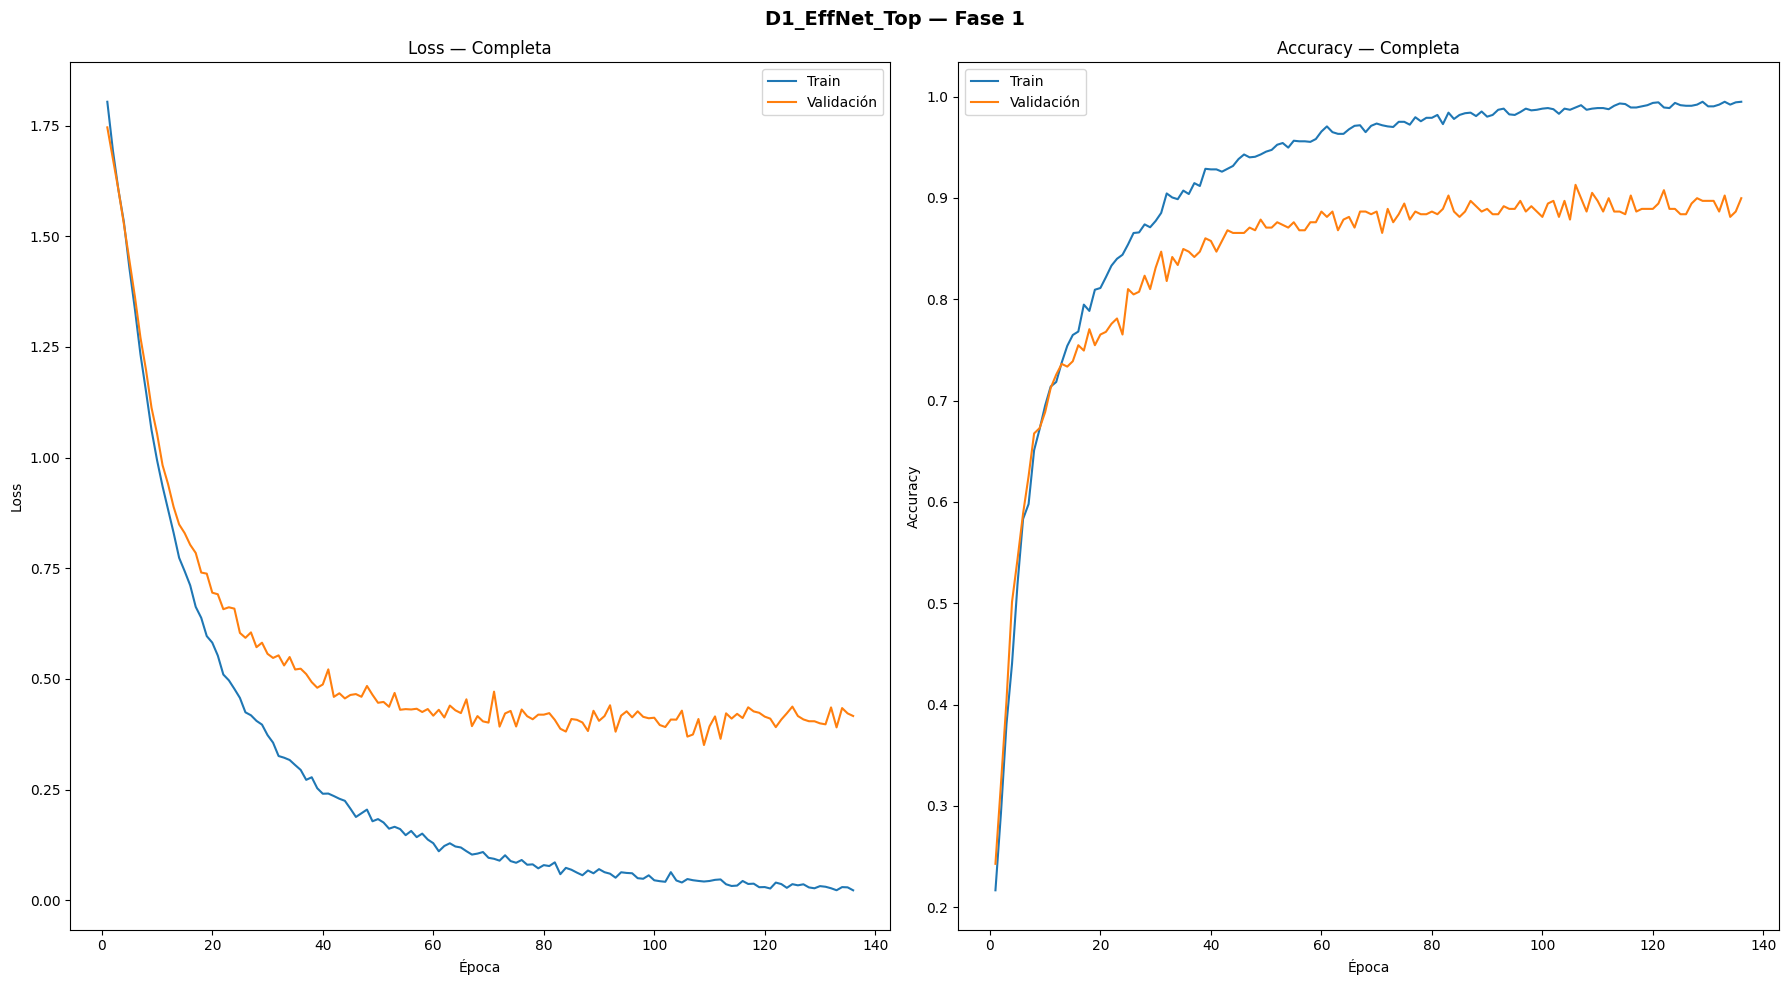

In [7]:
def smooth(values, weight=0.85):
    """Suavizado exponencial (similar a TensorBoard)."""
    smoothed, last = [], values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed


def plot_training(history, title='', phase=1):
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    epochs   = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    fig.suptitle(f'{title} — Fase {phase}', fontsize=14, fontweight='bold')

    # ── Fila 1: Loss ─────────────────────────────────────────────────────────
    # 1a) Curva completa
    axes[0].plot(epochs, loss,     label='Train')
    axes[0].plot(epochs, val_loss, label='Validación')
    axes[0].set_title('Loss — Completa')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    # ── Fila 2: Accuracy ─────────────────────────────────────────────────────
    axes[1].plot(epochs, acc,     label='Train')
    axes[1].plot(epochs, val_acc, label='Validación')
    axes[1].set_title('Accuracy — Completa')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()


    plt.tight_layout()
    plt.savefig(f'curvas_{MODEL_NAME}_fase{phase}.png', dpi=150)
    plt.show()


plot_training(history_p1, title=MODEL_NAME, phase=1)



---
## 5. Evaluación — Train / Val / Test


In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_split(model, ds, y_true, split_name):
    """Calcula métricas usando el dataset en batches (evita OOM en GPU)."""
    y_pred = np.argmax(model.predict(ds, verbose=0), axis=1)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'[{split_name:>5}]  Acc={acc:.4f}  Prec={prec:.4f}  '
          f'Rec={rec:.4f}  F1={f1:.4f}')
    return {'split': split_name, 'acc': acc,
            'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}

# Dataset de train SIN augmentation, solo para evaluación
ds_train_eval = make_dataset(X_train, y_train, training=False)

print('-' * 60)
print(f'Modelo: {MODEL_NAME}')
print('-' * 60)
res_train = evaluate_split(model, ds_train_eval, y_train, 'Train')
res_val   = evaluate_split(model, ds_val,        y_val,   'Val')
res_test  = evaluate_split(model, ds_test,       y_test,  'Test')
print('-' * 60)

------------------------------------------------------------
Modelo: D1_EffNet_Top
------------------------------------------------------------
[Train]  Acc=0.9887  Prec=0.9814  Rec=0.9906  F1=0.9858
[  Val]  Acc=0.9129  Prec=0.8999  Rec=0.9079  F1=0.9001


2026-03-13 18:56:46.710820: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 18:56:46.793639: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 18:56:47.070333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 18:56:47.155277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[ Test]  Acc=0.9289  Prec=0.9119  Rec=0.9207  F1=0.9148
------------------------------------------------------------


In [9]:
# ── Número de parámetros (para la tabla del README) ──────────────────────────
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f'Parámetros totales    : {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

Parámetros totales    : 6,248,790
Parámetros entrenables: 6,188,182


---
## 6. Matriz de confusión


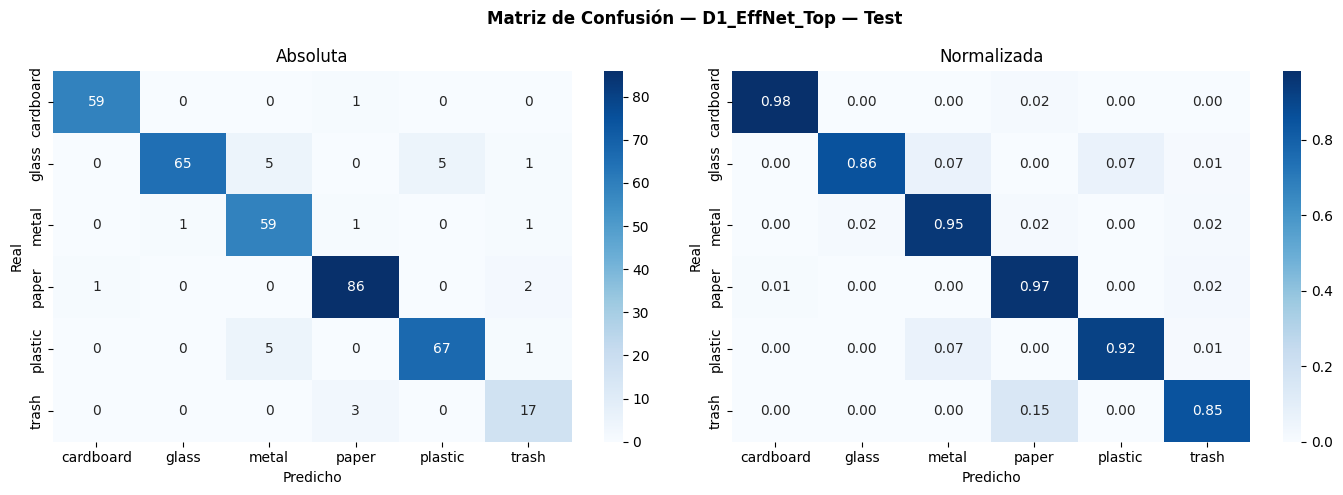

              precision    recall  f1-score   support

   cardboard       0.98      0.98      0.98        60
       glass       0.98      0.86      0.92        76
       metal       0.86      0.95      0.90        62
       paper       0.95      0.97      0.96        89
     plastic       0.93      0.92      0.92        73
       trash       0.77      0.85      0.81        20

    accuracy                           0.93       380
   macro avg       0.91      0.92      0.91       380
weighted avg       0.93      0.93      0.93       380



In [10]:
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title='Test'):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Matriz de Confusión — {title}', fontweight='bold')

    for ax, data, fmt, ttl in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Absoluta', 'Normalizada']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(ttl)
        ax.set_xlabel('Predicho')
        ax.set_ylabel('Real')

    plt.tight_layout()
    plt.savefig(f'confusion_{MODEL_NAME}.png', dpi=150)
    plt.show()


plot_confusion_matrix(y_test, res_test['y_pred'], title=f'{MODEL_NAME} — Test')
print(classification_report(y_test, res_test['y_pred'],
                             target_names=class_names))


---
## 7. Resumen 

In [11]:
print('─' * 90)
for res in [res_train, res_val, res_test]:
    print(
        f"| **{MODEL_NAME}** | {total_params:,} | {res['split']:>5} "
        f"| {res['acc']:.4f} | {res['prec']:.4f} "
        f"| {res['rec']:.4f} | {res['f1']:.4f} |"
    )
print('─' * 90)

──────────────────────────────────────────────────────────────────────────────────────────
| **D1_EffNet_Top** | 6,248,790 | Train | 0.9887 | 0.9814 | 0.9906 | 0.9858 |
| **D1_EffNet_Top** | 6,248,790 |   Val | 0.9129 | 0.8999 | 0.9079 | 0.9001 |
| **D1_EffNet_Top** | 6,248,790 |  Test | 0.9289 | 0.9119 | 0.9207 | 0.9148 |
──────────────────────────────────────────────────────────────────────────────────────────
